In [2]:
!pip install rasterio 
!pip install fiona
!pip install rasterstats
!pip install raster4ml
!pip install sklearn
!pip install shapely

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\flopes1\\OneDrive - Saint Louis University\\Desktop\\Repos\\plant-disease-prediction\\myenv\\Lib\\site-packages\\~iona.libs\\freexl-1-d8c800f2907b342d4f115f199a0eda45.dll'
Check the permissions.




  Using cached rasterstats-0.18.0-py3-none-any.whl (17 kB)
     ---------------------------------------- 0.0/74.9 kB ? eta -:--:--
     ---------------------------------------- 74.9/74.9 kB 4.0 MB/s eta 0:00:00
     ---------------------------------------- 0.0/21.7 MB ? eta -:--:--
     --- ------------------------------------ 1.6/21.7 MB 34.6 MB/s eta 0:00:01
     ------ --------------------------------- 3.4/21.7 MB 36.4 MB/s eta 0:00:01
     --------- ------------------------------ 5.2/21.7 MB 37.0 MB/s eta 0:00:01
     ------------- -------------------------- 7.5/21.7 MB 40.0 MB/s eta 0:00:01
     ----------------- ---------------------- 9.6/21.7 MB 41.0 MB/s eta 0:00:01
     --------------------- ----------------- 11.8/21.7 MB 43.5 MB/s eta 0:00:01
     ------------------------ -------------- 13.8/21.7 MB 46.7 MB/s eta 0:00:01
     ---------------------------- ---------- 15.8/21.7 MB 46.9 MB/s eta 0:00:01
     -------------------------------- ------ 18.2/21.7 MB 46.9 MB/s eta 0:00

  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> [18 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-pypi-packag

In [1]:
import numpy as np
import fiona
import rasterio.mask
from matplotlib import pyplot
import pandas as pd
import glob
import os
import rasterio
import raster4ml
from rasterio.crs import CRS
from rasterio.plot import show
from raster4ml.extraction import batch_extract_by_polygons, extract_shape_values
import os
import gc
import shutil


os.chdir(r'C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\\')

def create_directory(dir, name):
    # Directory
    directory = name

    # Parent Directory path
    parent_dir = dir

    # Path
    path = os.path.join(parent_dir, directory)

    # Create the directory
    if os.path.exists(path):
        shutil.rmtree(path)
    os.makedirs(path)

In [2]:
def get_bands(pixel_values):
    bands = dict.fromkeys(['blue', 'green', 'red', 'rede', 'nir'], [])
    bands['blue'] = pixel_values[0]
    bands['green'] = pixel_values[1]
    bands['red'] = pixel_values[2]
    bands['rede'] = pixel_values[3]
    bands['nir'] = pixel_values[4]
    return bands

def generate_indexes(dir, profile, bands):
    profile.update(
        dtype=rasterio.float32,
        count=1)
  
    create_directory(dir, "INDEXES")
    with rasterio.open(dir+"/INDEXES/blue.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['blue'].astype('float32'))
        del rst
        gc.collect()

    
    with rasterio.open(dir+"/INDEXES/green.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['green'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/red.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['red'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/rede.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['rede'].astype('float32'))
        del rst
        gc.collect()

    with rasterio.open(dir+"/INDEXES/nir.tif", 'w', **profile) as rst:
        rst.write_band(1, bands['nir'].astype('float32'))
        del rst
        gc.collect()

    NDVI = (bands['nir'] - bands['red']) / (bands['nir'] + bands['red'])
    with rasterio.open(dir+"/INDEXES/NDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDVI.astype('float32'))
        del rst
        gc.collect()

    GNDVI = (bands['nir']-bands['green'])/(bands['nir']+bands['green'])
    with rasterio.open(dir+"/INDEXES/GNDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, GNDVI.astype('float32'))
        del rst
        gc.collect()

    RVI_1 = bands['nir']/bands['red']
    with rasterio.open(dir+"/INDEXES/RVI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, RVI_1.astype('float32'))
        del rst
        gc.collect()

    GCI = (bands['nir']/bands['green'])-1.0
    with rasterio.open(dir+"/INDEXES/GCI.tif", 'w', **profile) as rst:
        rst.write_band(1, GCI.astype('float32'))
        del rst
        gc.collect()

    RGVI = bands['red']/bands['green']
    with rasterio.open(dir+"/INDEXES/RGVI.tif", 'w', **profile) as rst:
        rst.write_band(1, RGVI.astype('float32'))
        del rst
        gc.collect()

    DVI = bands['nir']-bands['red']
    with rasterio.open(dir+"/INDEXES/DVI.tif", 'w', **profile) as rst:
        rst.write_band(1, DVI.astype('float32'))
        del rst
        gc.collect()
    
    L = 0.5
    SAVI = ((bands['nir']-bands['red'])/(bands['nir']+bands['red']+L))*(1.0+L)
    with rasterio.open(dir+"/INDEXES/SAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, SAVI.astype('float32'))
        del rst
        gc.collect()

    MSAVI = 0.5*((2.0*bands['nir'])+1.0-np.sqrt(np.square(2.0*bands['nir']+1.0)-8.0*(bands['nir']-bands['red'])))
    with rasterio.open(dir+"/INDEXES/MSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, MSAVI.astype('float32'))
        del rst
        gc.collect()

    OSAVI = (bands['nir']-bands['red'])/(bands['nir']+bands['red']+0.16)
    with rasterio.open(dir+"/INDEXES/OSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, OSAVI.astype('float32'))
        del rst
        gc.collect()

    RDVI = np.sqrt((np.square(bands['nir']-bands['red']))/(bands['nir']+bands['red']))
    with rasterio.open(dir+"/INDEXES/RDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, RDVI.astype('float32'))
        del rst
        gc.collect()

    TVI = 60.0*(bands['nir']-bands['green'])-100.0*(bands['red']-bands['green'])
    with rasterio.open(dir+"/INDEXES/TVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TVI.astype('float32'))
        del rst
        gc.collect()

    a = 0.96916 
    b = 0.084726
    TSAVI = (a*(bands['nir']-a*bands['red']-b))/(a*bands['nir']+bands['red']-a*b)
    with rasterio.open(dir+"/INDEXES/TSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TSAVI.astype('float32'))
        del rst
        gc.collect()

    PVI = (bands['nir']-a*bands['red']-b)/np.sqrt(1+np.square(a))
    with rasterio.open(dir+"/INDEXES/TSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, TSAVI.astype('float32'))
        del rst
        gc.collect()

    SAVI_2 = bands['nir']/(bands['red']-(b/a))
    with rasterio.open(dir+"/INDEXES/SAVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, SAVI_2.astype('float32'))
        del rst
        gc.collect()

    X = 0.08
    ATSAVI= (a*(-a*bands['red']-b))/(a*bands['nir']+bands['red']-a*b+X*(1+np.square(a)))
    with rasterio.open(dir+"/INDEXES/ATSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, ATSAVI.astype('float32'))
        del rst
        gc.collect()

    NDWI = (bands['green']-bands['nir'])/(bands['green']+bands['nir'])
    with rasterio.open(dir+"/INDEXES/NDWI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDWI.astype('float32'))
        del rst
        gc.collect()

    NPCI = (bands['red']-bands['blue'])/(bands['red']+bands['blue'])
    with rasterio.open(dir+"/INDEXES/NPCI.tif", 'w', **profile) as rst:
        rst.write_band(1, NPCI.astype('float32'))
        del rst
        gc.collect()

    SRPI = bands['blue']/bands['red']
    with rasterio.open(dir+"/INDEXES/SRPI.tif", 'w', **profile) as rst:
        rst.write_band(1, SRPI.astype('float32'))
        del rst
        gc.collect()

    RVI_2 = bands['nir']/bands['green']
    with rasterio.open(dir+"/INDEXES/RVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, RVI_2.astype('float32'))
        del rst
        gc.collect()

    MCARI = (bands['rede']-bands['red']-0.2*(bands['rede']-bands['green']))*(bands['rede']/bands['red'])
    with rasterio.open(dir+"/INDEXES/MCARI.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI.astype('float32'))
        del rst
        gc.collect()

    MCARI_1 = 1.2*(2.5*(bands['nir']-bands['red'])-1.3*(bands['nir']-bands['green']))
    with rasterio.open(dir+"/INDEXES/MCARI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI_1.astype('float32'))
        del rst
        gc.collect()

    MCARI_2 = 1.5*(2.5*(bands['nir']-bands['red'])-1.3*(bands['nir']-bands['green']))*(np.square(2.0*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5
    with rasterio.open(dir+"/INDEXES/MCARI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, MCARI_2.astype('float32'))
        del rst
        gc.collect()

    MTVI_1 = 1.2*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))
    with rasterio.open(dir+"/INDEXES/MTVI_1.tif", 'w', **profile) as rst:
        rst.write_band(1, MTVI_1.astype('float32'))
        del rst
        gc.collect()

    MTVI_2 = 1.5*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))*(np.square(2*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5
    with rasterio.open(dir+"/INDEXES/MTVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, MTVI_2.astype('float32'))
        del rst
        gc.collect()

    R_MCARI_MTVI2 = ((bands['rede']-bands['red']-0.2*(bands['rede']-bands['green']))*(bands['rede']/bands['red']))/(1.5*(1.2*(bands['nir']-bands['green'])-2.5*(bands['red']-bands['green']))*(np.square(2*bands['nir']+1))-(6.0*bands['nir']-5.0*bands['red'])-0.5)
    with rasterio.open(dir+"/INDEXES/R_MCARI_MTVI2.tif", 'w', **profile) as rst:
        rst.write_band(1, R_MCARI_MTVI2.astype('float32'))
        del rst
        gc.collect()

    EVI = (bands['nir']-bands['red'])/(bands['nir']+6.0*bands['red']-7.5*bands['blue']+1.0)
    with rasterio.open(dir+"/INDEXES/EVI.tif", 'w', **profile) as rst:
        rst.write_band(1, EVI.astype('float32'))
        del rst
        gc.collect()

    DATT = (bands['nir']-bands['rede'])/(bands['nir']-bands['red'])
    with rasterio.open(dir+"/INDEXES/DATT.tif", 'w', **profile) as rst:
        rst.write_band(1, DATT.astype('float32'))
        del rst
        gc.collect()

    NDCI = (bands['rede']-bands['green'])/(bands['rede']+bands['green'])
    with rasterio.open(dir+"/INDEXES/NDCI.tif", 'w', **profile) as rst:
        rst.write_band(1, NDCI.astype('float32'))
        del rst
        gc.collect()

    PSRI = (bands['red']-bands['green'])/bands['rede']
    with rasterio.open(dir+"/INDEXES/PSRI.tif", 'w', **profile) as rst:
        rst.write_band(1, PSRI.astype('float32'))
        del rst
        gc.collect()

    SIPI = (bands['nir']-bands['blue'])/(bands['nir']+bands['red'])
    with rasterio.open(dir+"/INDEXES/SIPI.tif", 'w', **profile) as rst:
        rst.write_band(1, SIPI.astype('float32'))
        del rst
        gc.collect()

    SPVI = 0.4*3.7*(bands['nir']-bands['red'])-1.2*np.absolute(bands['green']-bands['red'])
    with rasterio.open(dir+"/INDEXES/SPVI.tif", 'w', **profile) as rst:
        rst.write_band(1, SPVI.astype('float32'))
        del rst
        gc.collect()

    TCARI = 3.0*((bands['rede']-bands['red'])-0.2*(bands['rede']-bands['green'])*(bands['rede']/bands['red']))
    with rasterio.open(dir+"/INDEXES/TCARI.tif", 'w', **profile) as rst:
        rst.write_band(1, TCARI.astype('float32'))
        del rst
        gc.collect()

    R_TCARI_OSAVI = (3.0*((bands['rede']-bands['red'])-0.2*(bands['rede']-bands['green'])*(bands['rede']/bands['red'])))/((bands['nir']-bands['red'])/(bands['nir']+bands['red']+0.16))
    with rasterio.open(dir+"/INDEXES/R_TCARI_OSAVI.tif", 'w', **profile) as rst:
        rst.write_band(1, R_TCARI_OSAVI.astype('float32'))
        del rst
        gc.collect()

    RERI = (bands['rede']-bands['red'])/bands['nir']
    with rasterio.open(dir+"/INDEXES/RERI.tif", 'w', **profile) as rst:
        rst.write_band(1, RERI.astype('float32'))
        del rst
        gc.collect()

    NDRE = (bands['nir']-bands['rede'])/(bands['nir']+bands['rede'])
    with rasterio.open(dir+"/INDEXES/NDRE.tif", 'w', **profile) as rst:
        rst.write_band(1, NDRE.astype('float32'))
        del rst
        gc.collect()

    MTCI = (bands['nir']-bands['rede'])/(bands['rede']-bands['red'])
    with rasterio.open(dir+"/INDEXES/MTCI.tif", 'w', **profile) as rst:
        rst.write_band(1, MTCI.astype('float32'))
        del rst
        gc.collect()

    EVI_2 = 2.5*((bands['nir']-bands['red'])/(bands['nir']+2.4*bands['red']+1.0))
    with rasterio.open(dir+"/INDEXES/EVI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, EVI_2.astype('float32'))
        del rst
        gc.collect()

    RECI = (bands['nir']/bands['rede'])-1
    with rasterio.open(dir+"/INDEXES/RECI.tif", 'w', **profile) as rst:
        rst.write_band(1, RECI.astype('float32'))
        del rst
        gc.collect()

    NEXG = (2*bands['green']-bands['red']-bands['blue'])/(bands['green']+bands['red']+bands['blue'])
    with rasterio.open(dir+"/INDEXES/NEXG.tif", 'w', **profile) as rst:
        rst.write_band(1, NEXG.astype('float32'))
        del rst
        gc.collect()

    NGRDI = (bands['green']-bands['red'])/(bands['green']+bands['red'])
    with rasterio.open(dir+"/INDEXES/NGRDI.tif", 'w', **profile) as rst:
        rst.write_band(1, NGRDI.astype('float32'))
        del rst
        gc.collect()

    ENDVI = (bands['nir']+bands['green']-2.0*bands['blue'])/(bands['nir']+bands['green']+2.0*bands['blue'])
    with rasterio.open(dir+"/INDEXES/ENDVI.tif", 'w', **profile) as rst:
        rst.write_band(1, ENDVI.astype('float32'))
        del rst
        gc.collect()

    ARI_2 = bands['nir']*((1.0/bands['green'])-(1.0/bands['rede']))
    with rasterio.open(dir+"/INDEXES/ARI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, ARI_2.astype('float32'))
        del rst
        gc.collect()

    CRI_2 = (1.0/bands['green'])-(1.0/bands['rede'])
    with rasterio.open(dir+"/INDEXES/CRI_2.tif", 'w', **profile) as rst:
        rst.write_band(1, CRI_2.astype('float32'))
        del rst
        gc.collect()

    #HERE WE CAN VISUALIZE THE INDEX MAPS
    #pyplot.imshow(NDVI)
    #pyplot.show()

    values = batch_extract_by_polygons(dir+"/INDEXES", 
                                       r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\PLOTBOUNDARIES\PLOTBOUNDARIES_PROJECT.shp",
                                       "ID", statistics=['mean'])
    create_directory(dir, "VALUES")
    
    disease_labels = extract_shape_values(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\PLOTBOUNDARIES\PLOTBOUNDARIES_PROJECT.shp",
                                        "ID", columns=['name', 'HEALTH_STA'])

    # Adding the column "health status" to the statistic summary
    values['HEALTH_STA'] = disease_labels['HEALTH_STA']
    values.to_csv(dir+"/VALUES/values.csv")
    
    # The code above calculates indexes and create a raster for each of them, then saves them into a folder

In [5]:
def normalize_pixels(pixel_values):
    pixel_values = (pixel_values - pixel_values.min()) / (pixel_values.max() - pixel_values.min()) 
    return pixel_values

"""
Considering the Chacabuco field and its 6 dates dataset
1. For each date:
1.1 Open the raster images
1.2 Get the pixels
1.3 Normalize pixel values
1.4 Get de bands values
1.5 Save specifc bands .tif images
1.6 Calculate indexes
"""
def main():
    dir_path = './'
    ignore_dir = "INDEXES"
    # Walks through the subdirectories and list files with .tif extension
    for root, dirs, files in os.walk(dir_path):
        print(dirs)
        if ignore_dir in dirs:
            dirs.remove("INDEXES")
            continue

        for file in files:
            if file.endswith(".tif"):
                file_path = os.path.join(root, file)
                # Open the file here
                with rasterio.open(file_path) as f:
                    print(f"File {file_path} opened with success!")

                    pixel_values = f.read()
                    profile = f.profile
                    del f
                    gc.collect()

                    pixel_values = normalize_pixels(pixel_values)
                    bands = get_bands(pixel_values)
                    del pixel_values
                    gc.collect()

                    generate_indexes(root, profile, bands)
                    del profile
                    del bands
                    gc.collect()

                    """
                    image_norm = (pixel_values - pixel_values.min()) / (pixel_values.max() - pixel_values.min()) 
                    del image_norm
                    gc.collect()

                    Now we can use the show function from rasterio, passing in the image to display it.
                    Note that this function expects the numpy array to be either a float ranging from 0 to 1, or an uint8 ranging from 0 to 255. 
                    Since our image is an uint16, we first normalize in order for it to render properly.
                    show(image_norm)
                """
main()

['08-30-2021', '09-24-2021', '10-05-2021', '10-07-2021', '10-26-2021', '11-17-2021', 'PLOTBOUNDARIES']
['INDEXES', 'VALUES']
[]
['INDEXES', 'VALUES']
[]
['INDEXES', 'VALUES']
[]
['INDEXES', 'VALUES']
[]
['INDEXES', 'VALUES']
[]
['INDEXES', 'VALUES']
[]
[]


In [7]:
!pip install scikit-learn
!pip install seaborn

     ---------------------------------------- 0.0/293.3 kB ? eta -:--:--
     ------------------------------------  286.7/293.3 kB 18.4 MB/s eta 0:00:01
     -------------------------------------- 293.3/293.3 kB 6.2 MB/s eta 0:00:00


     Unnamed: 0  ARI_2_mean  ATSAVI_mean  blue_mean  CRI_2_mean  DATT_mean  \
0             0    0.168315    -0.430586   0.366472    0.324576  -0.013853   
1             1    0.124244    -0.444310   0.382102    0.201459        NaN   
2             2    0.175280    -0.418316   0.394523    0.292705        NaN   
3             3    0.233481    -0.386434   0.343909    0.385195        NaN   
4             4    0.140918    -0.420997   0.375090    0.231699   0.021791   
..          ...         ...          ...        ...         ...        ...   
295         295    0.170469    -0.429390   0.395071    0.264352   0.048230   
296         296    0.122276    -0.453768   0.377906    0.180310        NaN   
297         297    0.198593    -0.419563   0.402199    0.316404  -0.092590   
298         298    0.221832    -0.429135   0.391541    0.386193        NaN   
299         299    0.254766    -0.415471   0.366627    0.436543  -0.014324   

     DVI_mean  ENDVI_mean      EVI_mean  EVI_2_mean  ...  R_MCA

ValueError: Target is multiclass but average='binary'. Please choose another average setting, one of [None, 'micro', 'macro', 'weighted'].

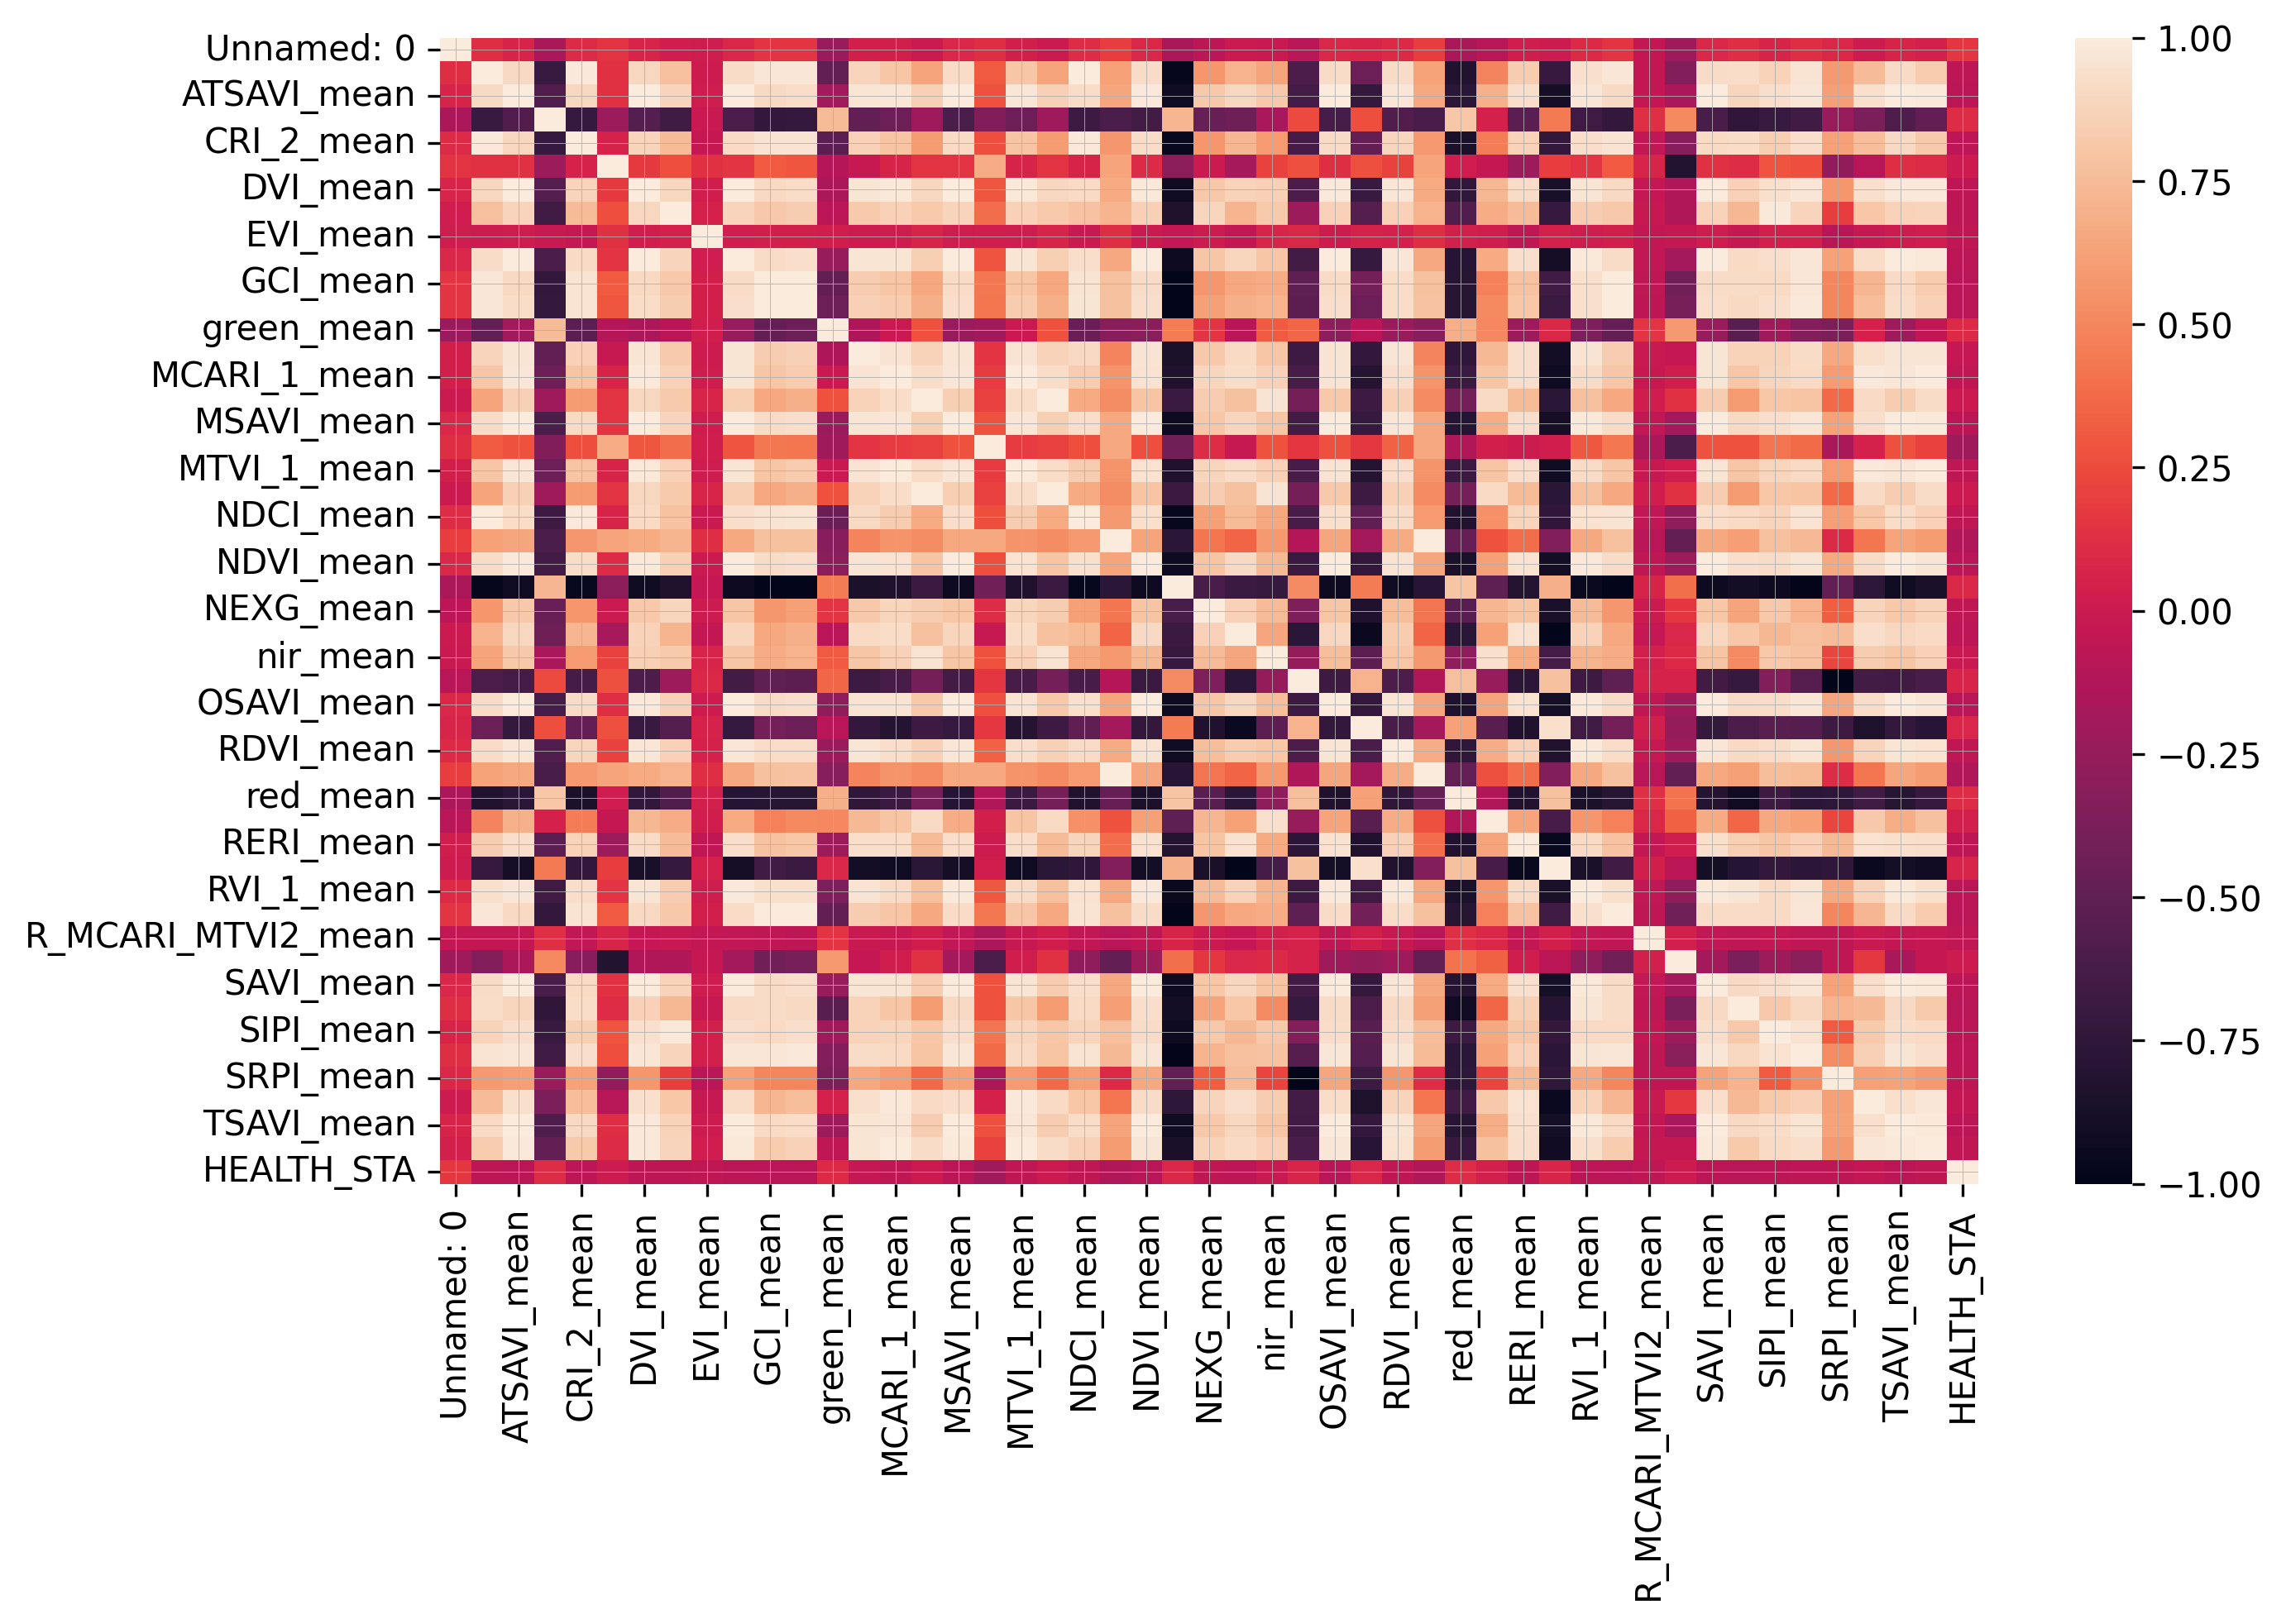

In [16]:

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import confusion_matrix, f1_score
from sklearn.svm import SVR
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import preprocessing

import geopandas as gpd
import numpy as np

df = pd.read_csv(r"C:\Users\flopes1\OneDrive - Saint Louis University\Desktop\Cahn\CHACABUCO\CHACABUCO\LARGO1\08-30-2021\VALUES\values.csv") 

df = df[df['HEALTH_STA'].notna()]
le = preprocessing.LabelEncoder()
le.fit(df['HEALTH_STA'])
df['HEALTH_STA'] = le.transform(df['HEALTH_STA'])

## Feature & Target Selection
X = df[[col for col in df.columns]]
X = X.drop('HEALTH_STA', axis=1)
y = df['HEALTH_STA']
y = y.dropna()

X.replace([np.inf, -np.inf], np.nan, inplace=True)
print(X)
print(X.shape)
mean_values = X.mean(axis=0)
X.fillna(mean_values, inplace=True)
print(X.shape)
print(y.shape)

min_max_scaler = preprocessing.MinMaxScaler()
x_scaled = min_max_scaler.fit_transform(X)
X = pd.DataFrame(x_scaled)


X = X.astype(float)
#X = np.where(X.values >= np.finfo(np.float64).max)
#print(np.shape(X))
# split data into train & test sets
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42)

y
# preview train & test sets
print('Train Set:', X_train.shape, y_train.shape)
print('Test Set:', X_test.shape, y_test.shape)
 
# build, train, & predict model
model = SVR()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# evaluate results
print('SVR')
print('MAE:', mean_absolute_error(y_pred, y_test))
print('MSE:', mean_squared_error(y_pred, y_test))
print('R2 Score:', r2_score(y_pred, y_test))

import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(10, 6), dpi=300)
ax.scatter(y_test, y_pred, color='green', s=5)

# Learn more about the options like color and s and many more
ax.set_xlabel('Actual Status')
ax.set_ylabel('Predicted Status')
#ax.set_title('Random Forest Regression')

# Predict and calculate the scores
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
plt.grid(linewidth = 0.2)
corr = df.corr()

import seaborn as sns
sns.heatmap(corr)

import numpy as np

from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
rf = RandomForestClassifier()
param_grid = { 
    'n_estimators': [200, 500],
    'max_features': [1, 'sqrt', 'log2'],
    'max_depth' : [4,5,6,7,8],
    'criterion' :['entropy', 'gini']
}

from scipy.stats import uniform
print('Random Forest Classifier')
rfc = RandomForestClassifier(random_state=42)
CV_rfc = GridSearchCV(estimator=rfc, param_grid=param_grid, cv= 5)

# fit
CV_rfc.fit(X_train, y_train)
print('Best Params:')
print(CV_rfc.best_params_)

# Instantiate RandomizedSearchCV model
rs_model = RandomizedSearchCV(RandomForestClassifier(n_jobs=-1, random_state=25),
                               param_distributions=param_grid,
                               n_iter=3,
                               cv=2,
                               verbose=True)
rs_model.fit(X_train, y_train)
print('Best Params (RF):')
print(rs_model.best_params_)
best_params = rs_model.best_params_

y_pred = rs_model.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('MSE: ', mse)
print('RMSE: ', rmse)
print('R2: ', r2)

print('Metrics (RFO)')
rfc_best = RandomForestClassifier(**best_params)
rfc_best.fit(X_train, y_train)
y_pred = rfc_best.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)
print('MSE: ', mse)
print('RMSE: ', rmse)
print('R2: ', r2)

f1 = f1_score(y_test, y_pred)
print('F1-SCORE: ', f1)
from sklearn.inspection import permutation_importance

fig, ax = plt.subplots(1, 1, figsize=(20, 20), dpi=70)
list_feature_importance = list(rfc_best.feature_importances_)
list_feature_importance

fig.suptitle('Random Forest Feature Importance', fontsize = 20)
ax.set_ylabel('Features',  fontsize = 18)
ax.set_xlabel('Feature Importance', fontsize = 18)
plt.figure(figsize=(20, 5))

print('Columns')
X.columns = [col for col in df.columns if col != 'HEALTH_STA']
print(X.columns)
ax.barh(y=X.columns, width=list_feature_importance)
ax.set_yticklabels(X.columns[sorted_idx], fontsize=14)
plt.tight_layout()
plt.show()

perm_importance = permutation_importance(model, X_test, y_test)
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
sorted_idx = perm_importance.importances_mean.argsort()
fig.suptitle('Permutation Importance', fontsize = 20)
plt.bar(np.array(X.columns)[sorted_idx], perm_importance.importances_mean[sorted_idx])
ax.set_xlabel('Feature Importance', fontsize = 18)
ax.set_xticklabels(np.array(X.columns)[sorted_idx], rotation = 90)

y

# Add confusion matrix to check real accuracy
# Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)
target_names = y.unique()
# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(cm, cmap='Blues')
ax.grid(False)
ax.set_xlabel('Predicted Labels', fontsize = 12, color = 'black')
ax.set_ylabel('True Labels', fontsize = 12, color = 'black')
ax.xaxis.set(ticks=np.arange(len(target_names)))
ax.yaxis.set(ticks=np.arange(len(target_names)))
ax.set_xticklabels(target_names, fontsize = 12, color = 'black')
ax.set_yticklabels(target_names, fontsize = 12, color = 'black')

# Loop over data dimensions and create text annotations.
for i in range(len(target_names)):
    for j in range(len(target_names)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="white", fontsize=14)

plt.show()

# Test the dataset for unhealthy
# Test using other dates as input
